In [1]:
from imports import *

In [2]:
result_list = glob.glob("stats/pi*")

print("Number of tested combinations: {}".format(len(result_list)))

Number of tested combinations: 10


In [3]:
result_list

['stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-mix--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-swp--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-inv--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n76-k7.evrp--mtr-0.800000--cor-0.700000--mtm-ins--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n76-k7.evrp--mtr-0.800000--cor-0.700000--mtm-inv--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.900000--cor-0.800000--mtm-mix--stp-1.500000--pop-16.txt',
 'stats\\pi-E-n76-k7.evrp--mtr-0.800000--cor-0.700000--mtm-mix--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.900000--cor-0.800000--mtm-swp--stp-1.500000--pop-16.txt',
 'stats\\pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-ins--stp-1.500000--pop-8.txt',
 'stats\\pi-E-n76-k7.evrp--mtr-0.800000--cor-0.700000--mtm-swp--stp-1.500000--pop-8.txt']

In [4]:
params = result_list[0].split("stats/")[-1].split(".txt")[0]

for i,kvalue in enumerate(params.split("--")):
    if i !=0:
        key,value = kvalue.split("-")

        print(key,value)


mtr 0.800000
cor 0.700000
mtm mix
stp 1.500000
pop 8


In [5]:
results = {}

for j, file in enumerate(result_list):

    results[j] = {
        "file_name": "",
        "routes": [],
        "r_fit": [],
        "best_route": 0,
        "mean_fit": [],
        "std_fit": 0,
        "max_fit": 0,
        "min_fit": 0,
    }

    results[j]["file_name"] = result_list[0].split("stats/")[-1].split(".txt")[0]

    with open(result_list[0], "r", encoding="utf-8") as file:

        for i, raw_line in enumerate(file):

            if i < 20:
                results[j]["routes"].append(
                    [
                        int(str_val)
                        for str_val in raw_line.split("route:")[-1].split(",")[:-1]
                    ]
                )
            elif i < 40:
                results[j]["r_fit"].append(float(raw_line))

            elif i == 40:
                results[j]["mean_fit"] = float(
                    raw_line.split("\t ")[:2][0].split("Mean "[-1])[1]
                )
                results[j]["std_fit"] = float(
                    raw_line.split("\t ")[:2][0].split("\tStd Dev "[-1])[1]
                )
            elif i == 41:
                results[j]["min_fit"] = float(raw_line.split("Min: ")[-1])

            elif i == 42:
                results[j]["max_fit"] = float(raw_line.split("Max: ")[-1])

        results[j]["r_fit"] = np.array(results[j]["r_fit"])

        results[j]["best_route"] = np.argsort(results[j]["r_fit"])[:1].item()

ValueError: can only convert an array of size 1 to a Python scalar

In [ ]:
results

{0: {'file_name': 'stats\\pi-E-n22-k4.evrp--mtr-0.900000--cor-0.800000--mtm-mix--stp-1.500000--pop-16',
  'routes': [[0,
    13,
    11,
    4,
    3,
    1,
    2,
    5,
    7,
    9,
    6,
    8,
    10,
    12,
    15,
    18,
    20,
    17,
    21,
    19,
    16,
    14,
    0],
   [0,
    13,
    11,
    4,
    3,
    1,
    2,
    5,
    7,
    9,
    6,
    8,
    10,
    12,
    15,
    18,
    20,
    17,
    21,
    19,
    16,
    14,
    0],
   [0,
    13,
    11,
    4,
    3,
    1,
    2,
    5,
    7,
    9,
    6,
    8,
    10,
    12,
    15,
    18,
    20,
    17,
    21,
    19,
    16,
    14,
    0],
   [0,
    13,
    11,
    4,
    3,
    1,
    2,
    5,
    7,
    9,
    6,
    8,
    10,
    12,
    15,
    18,
    20,
    17,
    21,
    19,
    16,
    14,
    0],
   [0,
    13,
    11,
    4,
    3,
    1,
    2,
    5,
    7,
    9,
    6,
    8,
    10,
    12,
    15,
    18,
    20,
    17,
    21,
    19,
    16,
    14,
    0],
   [0,
    13,
 


Instância: E-n22-k4.evrp
1º melhor | Fitness: 278.440000 | Mutação: mix | Execução: 1
2º melhor | Fitness: 278.440000 | Mutação: mix | Execução: 2
3º melhor | Fitness: 278.440000 | Mutação: mix | Execução: 3


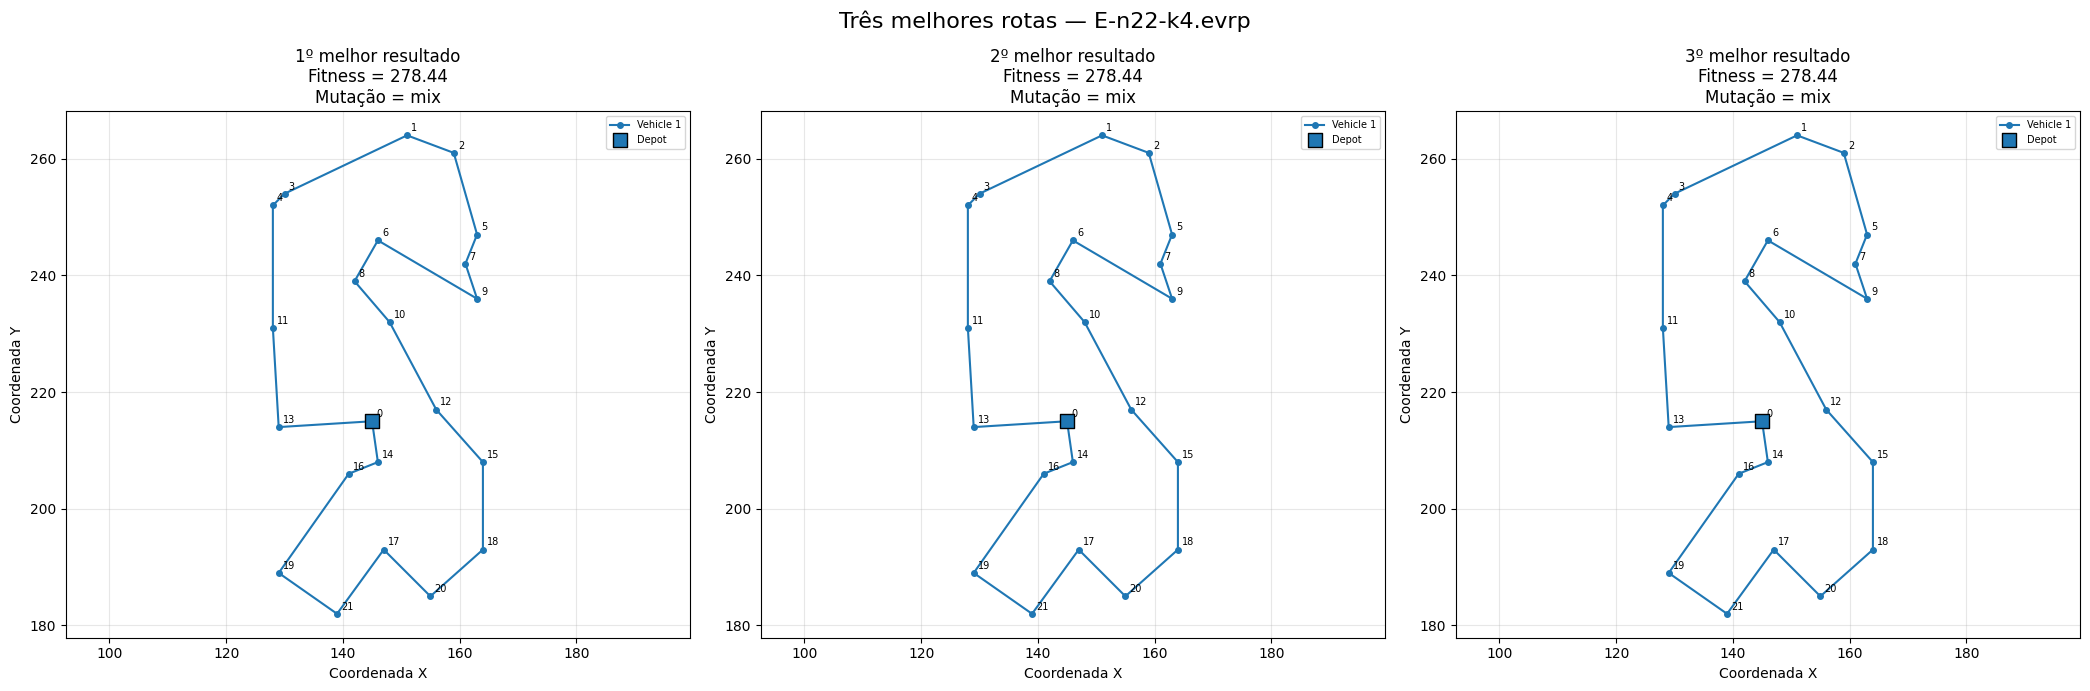

Figura salva em: route_plots\top_3_routes_E-n22-k4.png


In [ ]:
def get_instance_name_from_result(result_file):
    # Get only the file name
    file_name = os.path.basename(result_file)

    # Extract the instance name between "pi-" and "--mtr-"
    instance_name = file_name.split("pi-")[-1].split("--mtr-")[0]

    return instance_name


def get_mutation_method_from_result(result_file):
    # Get only the file name
    file_name = os.path.basename(result_file)

    # Extract the mutation method between "--mtm-" and "--"
    mutation_method = file_name.split("--mtm-")[-1].split("--")[0]

    return mutation_method


def read_routes_and_fitness(result_file):
    # Store the routes found in the result file
    routes = []

    # Store the fitness values found in the result file
    fitness_values = []

    # Open the result file
    with open(result_file, "r", encoding="utf-8") as result_data:

        # Read the file line by line
        for raw_line in result_data:

            # Remove spaces and line breaks
            line = raw_line.strip()

            # Ignore empty lines
            if line == "":
                continue

            # Read route lines
            if line.startswith("route:"):

                # Remove the word "route:"
                route_text = line.split("route:", 1)[1]

                # Convert the route nodes from text to integers
                route = [
                    int(value.strip())
                    for value in route_text.split(",")
                    if value.strip() != ""
                ]

                # Add the route to the route list
                routes.append(route)

            else:

                # Try to interpret the line as a fitness value
                try:
                    fitness_value = float(line)

                    # Add the fitness value to the list
                    fitness_values.append(fitness_value)

                # Ignore lines containing Mean, Std Dev, Min and Max
                except ValueError:
                    pass

    return routes, fitness_values


def find_instance_file(instance_name):
    # Search recursively for the EVRP instance
    instance_files = glob.glob(
        os.path.join("**", instance_name),
        recursive=True
    )

    # Return the first file found
    if len(instance_files) > 0:
        return instance_files[0]

    # Return None if the file was not found
    return None


def read_instance_coordinates(instance_file):
    # Store node coordinates
    coordinates = {}

    # Indicate whether the coordinate section is being read
    reading_coordinates = False

    # Open the EVRP instance file
    with open(instance_file, "r", encoding="utf-8") as instance_data:

        # Read the file line by line
        for raw_line in instance_data:

            # Remove spaces and line breaks
            line = raw_line.strip()

            # Ignore empty lines
            if line == "":
                continue

            # Start reading coordinates
            if line.upper() == "NODE_COORD_SECTION":
                reading_coordinates = True
                continue

            # Process the coordinate section
            if reading_coordinates:

                # Stop when another section begins
                if (
                    line.upper().endswith("_SECTION")
                    or line.upper() == "EOF"
                ):
                    break

                # Divide the line into columns
                parts = line.split()

                # A coordinate line must contain node, x and y
                if len(parts) >= 3:

                    try:
                        # Read the node identifier
                        node = int(float(parts[0]))

                        # Read the X coordinate
                        x_coordinate = float(parts[1])

                        # Read the Y coordinate
                        y_coordinate = float(parts[2])

                        # Store the node coordinates
                        coordinates[node] = (
                            x_coordinate,
                            y_coordinate
                        )

                    except ValueError:
                        pass

    return coordinates


def get_coordinate_offset(route, coordinates):
    # Count route nodes that directly exist in the coordinates
    direct_matches = sum(
        node in coordinates
        for node in route
    )

    # Count route nodes that exist after adding one
    shifted_matches = sum(
        node + 1 in coordinates
        for node in route
    )

    # Some EVRP files start node numbering at 1,
    # while the C++ route starts node numbering at 0
    if shifted_matches > direct_matches:
        return 1

    return 0


def split_route_by_vehicle(route):
    # Store each vehicle route
    vehicle_routes = []

    # Start the current route at the depot
    current_route = []

    # Read every node in the complete solution
    for node in route:

        # Add the node to the current vehicle route
        current_route.append(node)

        # Node zero represents the depot
        if node == 0 and len(current_route) > 1:

            # Save the completed vehicle route
            vehicle_routes.append(current_route)

            # Start the next vehicle route at the depot
            current_route = [0]

    # Save the final route if it was not closed
    if len(current_route) > 1:
        vehicle_routes.append(current_route)

    return vehicle_routes


def plot_one_solution(
    axis,
    route,
    coordinates,
    fitness,
    mutation_method,
    rank
):
    # Determine whether node identifiers require an offset
    coordinate_offset = get_coordinate_offset(
        route,
        coordinates
    )

    # Divide the complete solution into vehicle routes
    vehicle_routes = split_route_by_vehicle(route)

    # Plot each vehicle route
    for vehicle_index, vehicle_route in enumerate(vehicle_routes):

        # Store X coordinates
        x_values = []

        # Store Y coordinates
        y_values = []

        # Read each node in the vehicle route
        for node in vehicle_route:

            # Convert the route node to the coordinate identifier
            coordinate_node = node + coordinate_offset

            # Check whether the node has coordinates
            if coordinate_node in coordinates:

                # Get node coordinates
                x_coordinate, y_coordinate = coordinates[
                    coordinate_node
                ]

                # Add X coordinate
                x_values.append(x_coordinate)

                # Add Y coordinate
                y_values.append(y_coordinate)

        # Plot the current vehicle route
        axis.plot(
            x_values,
            y_values,
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=f"Vehicle {vehicle_index + 1}"
        )

    # Plot the node numbers
    for node in set(route):

        # Convert route node to coordinate identifier
        coordinate_node = node + coordinate_offset

        # Check whether the node exists
        if coordinate_node in coordinates:

            # Get node coordinates
            x_coordinate, y_coordinate = coordinates[
                coordinate_node
            ]

            # Add the node number beside the point
            axis.annotate(
                str(node),
                (x_coordinate, y_coordinate),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=7
            )

    # Get the depot coordinate identifier
    depot_node = coordinate_offset

    # Highlight the depot
    if depot_node in coordinates:

        # Get depot coordinates
        depot_x, depot_y = coordinates[depot_node]

        # Plot the depot using a square marker
        axis.scatter(
            depot_x,
            depot_y,
            marker="s",
            s=90,
            edgecolors="black",
            zorder=5,
            label="Depot"
        )

    # Create the plot title
    axis.set_title(
        f"{rank}º melhor resultado\n"
        f"Fitness = {fitness:.2f}\n"
        f"Mutação = {mutation_method}"
    )

    # Add the X-axis label
    axis.set_xlabel("Coordenada X")

    # Add the Y-axis label
    axis.set_ylabel("Coordenada Y")

    # Add a grid
    axis.grid(True, alpha=0.3)

    # Use the same scale on both axes
    axis.axis("equal")

    # Add the legend
    axis.legend(fontsize=7)


# Store every route from every result file
solutions_by_instance = {}


# Read each file in result_list
for result_file in result_list:

    # Extract the instance name
    instance_name = get_instance_name_from_result(
        result_file
    )

    # Extract the mutation method
    mutation_method = get_mutation_method_from_result(
        result_file
    )

    # Read routes and fitness values
    file_routes, file_fitness = read_routes_and_fitness(
        result_file
    )

    # Create the instance entry if it does not exist
    if instance_name not in solutions_by_instance:
        solutions_by_instance[instance_name] = []

    # Use the smallest size to avoid invalid positions
    number_of_solutions = min(
        len(file_routes),
        len(file_fitness)
    )

    # Associate each route with its respective fitness
    for run_index in range(number_of_solutions):

        # Add the solution to the instance
        solutions_by_instance[instance_name].append(
            {
                "route": file_routes[run_index],
                "fitness": file_fitness[run_index],
                "mutation_method": mutation_method,
                "run": run_index + 1,
                "result_file": result_file
            }
        )


# Create a folder to save the route figures
os.makedirs("route_plots", exist_ok=True)


# Process each EVRP instance
for instance_name, instance_solutions in solutions_by_instance.items():

    # Sort solutions by fitness in ascending order
    sorted_solutions = sorted(
        instance_solutions,
        key=lambda solution: solution["fitness"]
    )

    # Select the three best solutions
    top_three_solutions = sorted_solutions[:3]

    # Show the selected solutions
    print(f"\nInstância: {instance_name}")

    # Print information about each selected route
    for rank, solution in enumerate(
        top_three_solutions,
        start=1
    ):

        print(
            f"{rank}º melhor | "
            f"Fitness: {solution['fitness']:.6f} | "
            f"Mutação: {solution['mutation_method']} | "
            f"Execução: {solution['run']}"
        )

    # Search for the EVRP instance file
    instance_file = find_instance_file(instance_name)

    # Check whether the instance file was found
    if instance_file is None:

        print(
            f"Arquivo da instância não encontrado: "
            f"{instance_name}"
        )

        continue

    # Read the node coordinates
    coordinates = read_instance_coordinates(
        instance_file
    )

    # Check whether coordinates were found
    if len(coordinates) == 0:

        print(
            f"Coordenadas não encontradas em: "
            f"{instance_file}"
        )

        continue

    # Create one figure with three graphs
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(21, 7)
    )

    # Plot each of the three best routes
    for plot_index, solution in enumerate(
        top_three_solutions
    ):

        plot_one_solution(
            axis=axes[plot_index],
            route=solution["route"],
            coordinates=coordinates,
            fitness=solution["fitness"],
            mutation_method=solution["mutation_method"],
            rank=plot_index + 1
        )

    # Add a main title
    figure.suptitle(
        f"Três melhores rotas — {instance_name}",
        fontsize=16
    )

    # Adjust spacing
    figure.tight_layout()

    # Remove the EVRP extension from the output name
    output_instance_name = instance_name.replace(
        ".evrp",
        ""
    )

    # Define the output file
    output_file = os.path.join(
        "route_plots",
        f"top_3_routes_{output_instance_name}.png"
    )

    # Save the figure
    figure.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure
    plt.show()

    # Show the output file path
    print(f"Figura salva em: {output_file}")